In [1]:
#importando bibliotecas
import pandas as pd 
import numpy as np

r_cols = ['user_id', 'movie_id', 'rating'] #separação das colunas 
ratings = pd.read_csv(r'C:\Users\marya\Downloads\Dados\u.data', sep='\t', names=r_cols, usecols=range(3))
#criação do gráfico de livros puxando os dados de uma pasta no meu arquivo
ratings.head() #gera o dataframe com id 

,user_id,movie_id,rating
0,0,50,5
1,0,172,5
2,0,133,1
3,196,242,3
4,186,302,3


In [2]:
movieProperties = ratings.groupby('movie_id').agg({'rating': [np.size, np.mean]}) #gera o numero de avaliações e a média
movieProperties.head() #gera outro dataframe 

rating          
           size      mean
movie_id                 
1           452  3.878319
2           131  3.206107
3            90  3.033333
4           209  3.550239
5            86  3.302326

In [3]:
movieNumRatings = pd.DataFrame(movieProperties['rating']['size'])
#comparação do numero maxímo e minimo de avaliação de cada filme 
movieNormalizedNumRatings = movieNumRatings.apply(lambda x:(x - np.min(x)) / (np.max(x) - np.min(x)))
movieNormalizedNumRatings.head() #resultado

,size
movie_id,
1,0.773585
2,0.222985
3,0.152659
4,0.356775
5,0.145798


In [4]:
movieDict = {}
with open(r'C:\Users\marya\Downloads\Dados\u.item', encoding='ISO-8859-1') as f: #percorrerá cada linha do item u.item
    temp = ''
    for line in f:
        #extrai de dentro do arquivo o nome separado e o genero de cada filme sem a quebra de espaço
        fields = line.rstrip('\n').split('|')
        movieID = int(fields[0])
        name = fields[1]
        genres = fields[5:25]
        genres = list(map(int, fields[5:24]))
        #extrai o valor do ID do primeiro filme
        movieDict[movieID] = (name, genres, movieNormalizedNumRatings.loc[movieID].get('size'), movieProperties.loc[movieID].rating.get('mean'))

In [19]:
movieDict[1] #classificação média do filme do Toy Story

('Toy Story (1995)',
 [0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 np.float64(0.7735849056603774),
 np.float64(3.8783185840707963))

In [6]:
from scipy import spatial
import numpy as np

# Função para calcular a distância entre dois filmes com base na similaridade
def ComputeDistance(a, b):
    # Pega os gêneros do filme a e b
    genresA = list(a[1]) 
    genresB = list(b[1])
    # Calcula baseado na similaridade de cosseno entre os dois vetores de gênero
    genreDistance = spatial.distance.cosine(genresA, genresB)
    # Pega a pontuação de popularidade dos filmes a e b
    popularityA = a[2]
    popularityB = b[2]
    # A distância da popularidade é o valor absoluto da diferença entre as duas pontuações
    popularityDistance = abs(popularityA - popularityB)
    return genreDistance + popularityDistance
    
ComputeDistance(movieDict[2], movieDict[4])

np.float64(0.8004574042309892)

In [7]:
movieDict[2] #imprime as informações dos filmes 

('GoldenEye (1995)',
 [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
 np.float64(0.22298456260720412),
 np.float64(3.2061068702290076))

In [8]:
movieDict[4]

('Get Shorty (1995)',
 [0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 np.float64(0.3567753001715266),
 np.float64(3.550239234449761))

In [20]:
import operator

def getNeighbors(movieID, K):
    distances = []
    # Para todos os filmes do dicionário
    for movie in movieDict:
        # Se o filme for diferente do que estou analisando
        if (movie != movieID):
            # Ele calcula a pontuação de distância anterior
            dist = ComputeDistance(movieDict[movieID], movieDict[movie])
            # Adiciona na lista de resultados
            distances.append((movie, dist))
    # Ordenará os resultados
    distances.sort(key=operator.itemgetter(1))
    neighbors = []
    # Aqui ele vai selecionar os melhores resultados
    for x in range(K):
        neighbors.append(distances[x][0])
    # Retorna esses resultados
    return neighbors

K = 10
avgRating = 0
neighbors = getNeighbors(1, K)
# Calcula a classificação média de cada um, essa classificação informará a previsão 
for neighbor in neighbors:
    avgRating += movieDict[neighbor][3]
    print (movieDict[neighbor][0] + " " + str(movieDict[neighbor][3]))
avgRating /= K

Liar Liar (1997) 3.156701030927835
Aladdin (1992) 3.8127853881278537
Willy Wonka and the Chocolate Factory (1971) 3.6319018404907975
Monty Python and the Holy Grail (1974) 4.0664556962025316
Full Monty, The (1997) 3.926984126984127
George of the Jungle (1997) 2.685185185185185
Beavis and Butt-head Do America (1996) 2.7884615384615383
Birdcage, The (1996) 3.4436860068259385
Home Alone (1990) 3.0875912408759123
Aladdin and the King of Thieves (1996) 2.8461538461538463


In [21]:
avgRating

np.float64(3.3445905900235564)

In [5]:
movieDict[1]

('Toy Story (1995)',
 [0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 np.float64(0.7735849056603774),
 np.float64(3.8783185840707963))

### PCA Análise Principal de Componentes 

In [6]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import pylab as pl
from itertools import cycle

iris = load_iris() #extrair informações

numSample, numFeatures = iris.data.shape #extraindo o formato e a quantidade de pontos
print (numSamples) #imprime a quantidade de espécimes de íris
print (numFeatures) #imprime as dimensões 
print (list(iris.target_names)) #imprime a lista de nomes dos alvos neste conjunto de dados

NameError: name 'numSamples' is not defined

In [ ]:
iris = load_iris()
X = iris.data #atribui o conjunto de dados iris
pca = PCA(n_components=2, whiten=True).fit(X) #define um pca e define os componentes para buscar 2 dimensões 
X_pca = pca.transform(X) #transforma o conjunto de dados em duas dimensões

In [ ]:
#esses componentes principais são os autovetores que escolhemos para definir planos
print (pca.components_) #imprime os componetes reais de uma pca

In [ ]:
#quantidade de variance nos dados de quatro dimensões que foi preservado para reduzir para duas dimensões e não ser quatro
print (pca.explained_variance_ratio_)
print (sum (pca.explained_variance_ratio_))

In [ ]:
#No vídeo o gráfico ficou misturado, o meu por ser python 3 ficaram separados
colors = cycle('rgb') #cores diferentes
target_ids = range(len(iris.target_names)) #IDs de alvos, mapear as diferentes espécies de íris
pl.figure()
for i, c, label in zip (target_ids, colors, iris.target_names): #mistura com os nomes reais de cada espécie
    pl.scatter(X_pca[iris.target == i, 0], X_pca[iris.target == i, 1],
              c=c, label=label) #gráfico de dispersão para cada espécie e diferentes cores 
    pl.legend()
    pl.show()

### Aprendizagem por Reforço

In [7]:
import gymnasium as gym #importando o gym, meu não estava funcionando o gym fiz uma pesquisa e tive que instalar o gymnasium
import random #importando o random

random.seed(1234)

streets = gym.make("Taxi-v3",render_mode="ansi").env
streets.reset()

print("\n" + streets.render())


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




In [14]:
initial_state = streets.unwrapped.encode(2, 3, 2, 0) #.unwrapped para acessar as funções específicas do Taxi

streets.unwrapped.s = initial_state #.unwrapped para definir o estado 's' diretamente

print(streets.render())

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




In [18]:
streets.unwrapped.P[initial_state] 

{0: [(1.0, 368, -1, False)],
 1: [(1.0, 168, -1, False)],
 2: [(1.0, 288, -1, False)],
 3: [(1.0, 248, -1, False)],
 4: [(1.0, 268, -10, False)],
 5: [(1.0, 268, -10, False)]}

In [ ]:
import numpy as np #importando numpy 
import random
#Treinar 100000 corridas de taxi simuladas 

q_table = np.zeros([streets.observation_space.n, streets.action_space.n]) #tabelas de dicas 

#praticamente define a velocidade e o fator de desconto, todos os parâmentros são inseridos na equação de aprendizado
learning_rate = 0.1
discount_factor = 0.6
exploration = 0.1
epochs = 10000

#percorre todas os 10%, após as corridas de taxi é reiniciado
for taxi_run in range(epochs):
    state, info = streets.reset()
    done = False
    #primeiro é sorteado um número aleatório de 0 a 1
    while not done:
        random_value = random.uniform(0, 1)
        if(random_value < exploration):
            action = streets.action_space.sample() #explore a random action
        else:
            action = np.argmax(q_table[state]) #Use the action with the highest q-value 
        
        next_state, reward, terminated, truncated, info = streets.step(action)#usado para aplicar a ação utilizada acima
        
        prev_q = q_table[state, action]
        next_max_q = np.max(q_table[next_state])
        
        new_q = (1 - learning_rate) * prev_q + learning_rate * (reward + discount_factor * next_max_q)
        q_table[state, action] = new_q

        state = next_state

In [ ]:
q_table[initial_state]

In [ ]:
from IPython.display import clear_output 
from time import sleep

for tripnum in range(1, 11):
    state = streets.reset()

    done = False

    while not done:
        action = np.argmax(q_table[atate])
        next_stage, reward, done, info = streets.ste(action)
        clear_output(wait=True)
        print("trip number" + str(tripnum))
        print(streets.render(mode="ansi"))
        sleep(.5)
        state = next_state

    sleep(2) 

### Dealing with Real World Data

In [3]:
# K-fold Cross Validation 
import numpy as np 
from sklearn import model_selection #cross_validation
from sklearn import datasets
from sklearn import svm

iris = datasets.load_iris()

In [8]:
#Divida os dados da íris em conjuntos de dados de treino e teste, reservando 40% para o conjunto de teste.
X_train, X_test, y_train, y_test = model_selection.train_test_split(iris.data, iris.target, test_size=0.4, random_state=0)#cross_validation
#Construa um modelo SVC para prever classificações de íris usando dados de treinamento.
clf = svm.SVC(kernel='linear', C=1).fit(X_train, y_train)
#Agora meça seu desempenho com os dados de teste.
clf.score(X_test, y_test)

0.9666666666666667

In [11]:
#Fornecemos cross_val_score um modelo, o conjunto completo e seus valores "reais", bem como o número de dobras:
score = model_selection.cross_val_score(clf, iris.data, iris.target, cv=5)
#Imprima a precisão para cada dobra.
print(score)
#E a precisão média de todas as 5 dobras
print(score.mean())

[0.96666667 1.         0.96666667 0.96666667 1.        ]
0.9800000000000001


In [15]:
clf = svm.SVC(kernel='poly', C=1).fit(X_train, y_train)
score = model_selection.cross_val_score(clf, iris.data, iris.target, cv=5)
print (score)
print (score.mean())

[0.96666667 1.         0.96666667 0.96666667 1.        ]
0.9800000000000001


In [17]:
#Construir um modelo SVC para prever classificações de íris usando dados de treinamento.
clf = svm.SVC(kernel='poly', C=1).fit(X_train, y_train)
#Agora meça seu desempenho com os dados de teste
clf.score(X_test, y_test)

0.9

### Cleaning Your Data

### Motivo de não completar a tarefa da aula
#### Por algum motivo não quer reconhecer a pasta com os arquivos e não quer funiconar, pra não ficar com a mensagem de erro troquei o código original e adicionei (with open(logPath, "r", encoding="latin-1") as f:) pq assim o código não da erro, fiz pesquisa, tentei resolver por fora mas não funcionou, na hora de fazer o arquivo de prática vou tentar fazer funcionar do jeito certo.

In [75]:
import re #importando re

#analisa uma linha de log de acesso do apache e a divide em vários campos 
format_pat = re.compile(
    r"(?P<host>[\d\.]+) \s"
    r"(?P<identity>\S+) \s"
    r"(?P<user>\S+) \s"
    r"\[(?P<time>.*?)\] \s"
    r'"(?P<request>.*?)" \s '
    r"(?P<status>\d+) \s"
    r"(?P<bytes>\S+) \s"
    r'"(?P<referer>.*?)" \s'
    r'"(?P<user_agent>.*?)"\s*'
)

In [98]:
logPath = r"C:\Users\marya\Downloads\Dados\Dados.txt" #utilizando um site para a captura de dados 

In [104]:
URLCounts = {}
with open(logPath, "r", encoding="latin-1") as f:
    for line in (l.rstrip() for l in f):
        match = format_pat.match(line)
        if match:
            access = match.groupdict()
            request = access.get('request') or access.get('rquest')
            
            if request:
                parts = request.split()
                if len(parts) == 3:
                    action, URL, protocol = parts
                    # Usando .get() para simplificar a contagem
                    URLCounts[URL] = URLCounts.get(URL, 0) + 1

# Ordenação e exibição 
results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)

for result in results[:20]:
    print(f"{result}: {URLCounts[result]}")

In [103]:
URLCounts = {}
# abre o arquivo
with open(logPath, "r", encoding="latin-1") as f:
    # processa cada linha, removendo espaços em branco
    for line in (l.rstrip() for l in f):
        # retorna o resultado da correspondência
        match = format_pat.match(line)
        if match:
            # pega os dados nomeados em um dicionario
            access = match.groupdict()
            # pega a requisicao
            request = access['request']
            # divide os campos da requisicao
            fields = request.split()
            # se tiver diferente de 3 campos, mostra a linha
            if (len(fields) != 3):
                print(fields)

In [51]:
URLCounts = {}

with open(logPath, "r", encoding="latin-1") as f:
    for line in (l.rstrip() for l in f):
        match = format_pat.match(line)
        if match:
            access = match.groupdict()
            request = access['request']
            fields = request.split()
            # Adicionando essa linha apenas, que verifica se existem 3 campos
            if (len(fields) == 3):
                URL = fields[1] # url é o segundo campo da requisicao
                if URL in URLCounts:
                    URLCounts[URL] += 1
                else:
                    URLCounts[URL] = 1

results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)

for result in results[:20]:
    print (result + ": " + str(URLCounts[result]))

In [52]:
URLCounts = {}

with open(logPath, "r", encoding="latin-1") as f:
    for line in (l.rstrip() for l in f):
        match = format_pat.match(line)

        if match:

            access = match.groupdict()
            request = access['request']
            fields = request.split()

            if (len(fields) == 3):

                # adicionando novamente a separação dos campos
                (action, URL, protocol) = fields

                # adicionando a verificação para ver se a ação é GET
                if (action == 'GET'):

                    if URL in URLCounts:
                        URLCounts[URL] += 1
                    else:
                        URLCounts[URL] = 1

results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)

for result in results[:20]:
    print (result + ": " + str(URLCounts[result]))

In [55]:
# dicionario para armazenar as contagens de User Agents
UserAgents = {}

with open(logPath, "r", encoding="latin-1") as f:
    for line in (l.rstrip() for l in f):
        match = format_pat.match(line)
        if match:
            access = match.groupdict()

            # dessa vez pega apenas o agente do acesso
            agent = access['user_agent']

            # se o agente ja estiver no dicionario, incrementa
            if agent in UserAgents:
                UserAgents[agent] = UserAgents[agent] + 1

            # se não, inicializa com 1
            else:
                UserAgents[agent] = 1

results = sorted(UserAgents, key=lambda i: int(UserAgents[i]), reverse=True)

# mostra os 20 mais comuns
for result in results:
    print (result + ": " + str(UserAgents[result]))

In [56]:
URLCounts = {}

with open(logPath, "r", encoding="latin-1") as f:
    for line in (l.rstrip() for l in f):
        match = format_pat.match(line)
        if match:
            access = match.groupdict()

            # adicionando essa linha para pegar o user agent
            agent = access['user_agent']

            # verificando se o user agent não é um bot
            if (not ('bot' in agent or 'spider' in agent or
                     'Bot' in agent or 'W3 Total Cache' in agent or agent == '-')):
                
                request = access['request']
                fields = request.split()
                if (len(fields) == 3):
                    (action, URL, protocol) = fields
                    if (action == 'GET'):
                        if URL in URLCounts:
                            URLCounts[URL] = URLCounts[URL] + 1
                        else:
                            URLCounts[URL] = 1

results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)

for result in results[:20]:
    print (result + ": " + str(URLCounts[result]))

In [57]:
URLCounts = {}
with open(logPath, "r", encoding="latin-1") as f:
    for line in (l.rstrip() for l in f):
        match = format_pat.match(line)
        if match:
            access = match.groupdict()
            agent = access['user_agent']
            if (not ('bot' in agent or 'spider' in agent or
                     'Bot' in agent or 'W3 Total Cache' in agent or agent == '-')):
                request = access['request']
                fields = request.split()
                if (len(fields) == 3):
                    (action, URL, protocol) = fields

                    # adicionando a verificação para ver se é um site (termina com "/")
                    if (URL.endswith("/")):
                        if (action == 'GET'):
                            if URL in URLCounts:
                                URLCounts[URL] = URLCounts[URL] + 1
                            else:
                                URLCounts[URL] = 1

results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)

for result in results[:20]:
    print (result + ": " + str(URLCounts[result]))

In [59]:
# dicionario para armazenar as contagens de URL
URLCounts = {}

# abre o arquivo
with open(logPath, "r", encoding="latin-1") as f:

    # processa cada linha, removendo espaços em branco ou \n
    for line in (l.rstrip() for l in f):

        # tenta aplicar o match de cada linha do log
        match = format_pat.match(line)

        # se retornou alguma coisa
        if match:

            # pega os dados nomeados em um dicionario
            access = match.groupdict()
            # pega o agente
            agent = access['user_agent']
            # verifica se não é bot
            if (not ('bot' in agent or 'spider' in agent or
                     'Bot' in agent or 'W3 Total Cache' in agent or agent == '-')):
                
                # pega o request
                request = access['request']
                # separa os campos da requisicao
                fields = request.split()

                # se tiver 3 campos continua
                if (len(fields) == 3):
                    # pega os 3 campos
                    (action, URL, protocol) = fields

                    # verifica se não é um feed
                    if ('feed' not in URL):

                        # verifica se é um site (termina com "/")
                        if (URL.endswith("/")):

                            # verifica se a ação é GET
                            if (action == 'GET'):

                                # verifica se a URL já está no dicionario
                                if URL in URLCounts:
                                    URLCounts[URL] = URLCounts[URL] + 1
                                # se não, inicializa com 1
                                else:
                                    URLCounts[URL] = 1

# ordena os resultados pela contagem
results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)

# mostra os 20 mais acessados
for result in results[:20]:
    print (result + ": " + str(URLCounts[result]))

In [58]:
URLCounts = {}

with open(logPath, "r", encoding="latin-1") as f:
    for line in (l.rstrip() for l in f):
        match = format_pat.match(line)
        if match:

            access = match.groupdict()
            agent = access['user_agent']
            request = access['request']
            fields = request.split()

            # removi a verificação de bot

            if (len(fields) == 3):
                (action, URL, protocol) = fields

                # mostra apenas as url que tem feed
                if ('feed' in URL):

                    # removi quaisquer outras verificações

                    if URL in URLCounts:
                        URLCounts[URL] = URLCounts[URL] + 1
                    else:
                        URLCounts[URL] = 1

results = sorted(URLCounts, key=lambda i: int(URLCounts[i]), reverse=True)
for result in results[:20]:
    print (result + ": " + str(URLCounts[result]))
    print("Agent: " + agent)

## Dealing with Outliers

<function matplotlib.pyplot.show(close=None, block=None)>

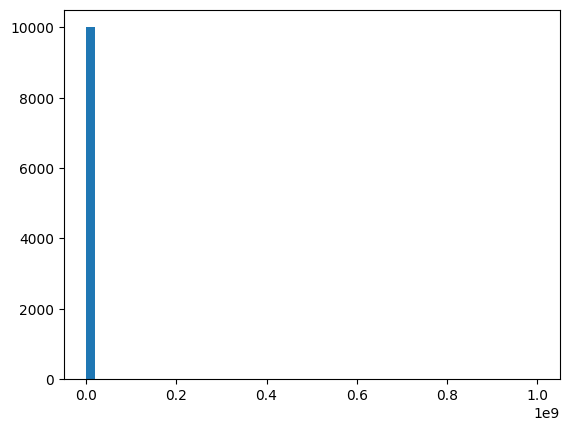

In [106]:
%matplotlib inline
import numpy as np

incomes = np.random.normal(2700, 1500, 10000)
incomes = np.append(incomes, [1000000000])

import matplotlib.pyplot as plt
plt.hist(incomes, 50)
plt.show

In [107]:
incomes.mean()

np.float64(102693.21126536238)

<function matplotlib.pyplot.show(close=None, block=None)>

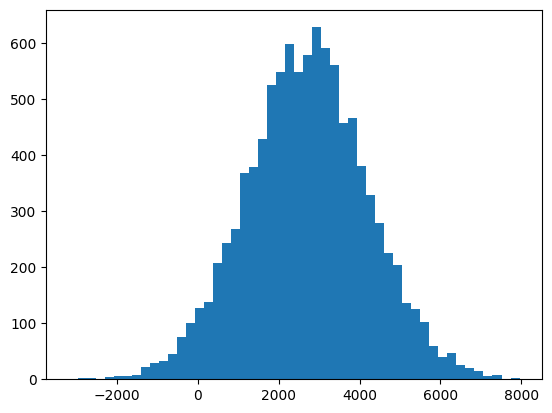

In [110]:
def reject_outliers(data):
    u = np.median(data)
    s = np.std(data)
    filtered = [e for e in data if (u - 2 * s < e < u + 2 * s)]
    return filtered

filtered = reject_outliers(incomes)
plt.hist(filtered, 50)
plt.show


In [111]:
np.mean(filtered)

np.float64(2703.4805864889304)